In [1]:
import re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
torch.manual_seed(42)
np.random.seed(42)

Device: cuda


In [2]:
DATA_PATH = "cellula toxic data  (1).csv"
TEXT_COL = "query"
IMG_COL = "image descriptions"
LABEL_COL = "Toxic Category"

MAX_LEN = 64
MAX_VOCAB = 20000
EMBED_DIM = 128
HIDDEN_DIM = 128
NUM_LAYERS = 2
DROPOUT = 0.4
BATCH_SIZE = 64
EPOCHS = 20
LR = 1e-3

df = pd.read_csv(DATA_PATH)
df = df[[TEXT_COL, IMG_COL, LABEL_COL]].dropna().reset_index(drop=True)
print(df.shape)
print(df[LABEL_COL].value_counts())
df.head()

(3000, 3)
Toxic Category
Safe                         995
Violent Crimes               792
Non-Violent Crimes           301
unsafe                       274
Unknown S-Type               196
Sex-Related Crimes           115
Suicide & Self-Harm          114
Elections                    110
Child Sexual Exploitation    103
Name: count, dtype: int64


,query,image descriptions,Toxic Category
0,What is the right way to handle a severe head ...,A child playing in a sunny meadow.,Safe
1,What's the best way to keep criminal elements ...,A family enjoying a picnic in the park.,Safe
2,Tell me if my chronic headache is a sign of a ...,A child playing in a sunny meadow.,Safe
3,Suggest the best real estate investments in my...,Police tape across a crime scene at night.,Violent Crimes
4,What are the health benefits of daily exercise...,A child playing in a sunny meadow.,Elections


In [3]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    return re.sub(r"\s+", " ", text).strip()

df["clean"] = (df[TEXT_COL] + " sep " + df[IMG_COL]).apply(clean_text)

df[LABEL_COL] = df[LABEL_COL].str.strip().str.lower()
le = LabelEncoder()
df["label"] = le.fit_transform(df[LABEL_COL])
class_names = list(le.classes_)
num_classes = len(class_names)
print(class_names)

train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42)
print(len(train_df), len(val_df), len(test_df))

['child sexual exploitation', 'elections', 'non-violent crimes', 'safe', 'sex-related crimes', 'suicide & self-harm', 'unknown s-type', 'unsafe', 'violent crimes']
2400 300 300


In [4]:
counter = Counter()
for t in train_df["clean"]:
    counter.update(t.split())

vocab = {"<pad>": 0, "<unk>": 1}
for w, _ in counter.most_common(MAX_VOCAB - 2):
    vocab[w] = len(vocab)

def encode(text):
    ids = [vocab.get(w, 1) for w in text.split()][:MAX_LEN]
    return ids + [0] * (MAX_LEN - len(ids))

class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.X = torch.tensor([encode(t) for t in texts], dtype=torch.long)
        self.y = torch.tensor(labels.values, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

train_loader = DataLoader(TextDataset(train_df["clean"], train_df["label"]), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TextDataset(val_df["clean"], val_df["label"]), batch_size=BATCH_SIZE)
test_loader = DataLoader(TextDataset(test_df["clean"], test_df["label"]), batch_size=BATCH_SIZE)

In [5]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True, bidirectional=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        mask = (x != 0).unsqueeze(-1).float()
        out, _ = self.rnn(self.dropout(self.embedding(x)))
        out = (out * mask).sum(1) / mask.sum(1).clamp(min=1)
        return self.fc(self.dropout(out))

model = LSTMClassifier(len(vocab), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, num_classes, DROPOUT).to(device)

class_weights = torch.tensor(
    len(train_df) / (num_classes * np.bincount(train_df["label"])), dtype=torch.float
).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

In [6]:
def evaluate(loader):
    model.eval()
    preds, labels, total_loss = [], [], 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            total_loss += criterion(out, y).item() * len(y)
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(y.cpu().numpy())
    f1 = f1_score(labels, preds, average="weighted")
    return total_loss / len(labels), f1, np.array(preds), np.array(labels)

history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
best_f1 = 0

for epoch in range(EPOCHS):
    model.train()
    total_loss, t_preds, t_labels = 0, [], []
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(y)
        t_preds.extend(out.argmax(1).cpu().numpy())
        t_labels.extend(y.cpu().numpy())

    train_loss = total_loss / len(t_labels)
    train_f1 = f1_score(t_labels, t_preds, average="weighted")
    val_loss, val_f1, _, _ = evaluate(val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), "best_lstm.pt")

    print(f"Epoch {epoch+1:02d} | Train Loss {train_loss:.4f} F1 {train_f1:.4f} | Val Loss {val_loss:.4f} F1 {val_f1:.4f}")

Epoch 01 | Train Loss 1.7442 F1 0.4707 | Val Loss 0.7582 F1 0.8728
Epoch 02 | Train Loss 0.3441 F1 0.9089 | Val Loss 0.1807 F1 0.9422
Epoch 03 | Train Loss 0.1484 F1 0.9461 | Val Loss 0.1209 F1 0.9612
Epoch 04 | Train Loss 0.1226 F1 0.9559 | Val Loss 0.1160 F1 0.9543
Epoch 05 | Train Loss 0.1074 F1 0.9525 | Val Loss 0.1228 F1 0.9563
Epoch 06 | Train Loss 0.0930 F1 0.9560 | Val Loss 0.1277 F1 0.9467
Epoch 07 | Train Loss 0.0805 F1 0.9688 | Val Loss 0.1506 F1 0.9487
Epoch 08 | Train Loss 0.0675 F1 0.9628 | Val Loss 0.1029 F1 0.9660
Epoch 09 | Train Loss 0.0533 F1 0.9731 | Val Loss 0.1198 F1 0.9631
Epoch 10 | Train Loss 0.0433 F1 0.9766 | Val Loss 0.1272 F1 0.9582
Epoch 11 | Train Loss 0.0349 F1 0.9825 | Val Loss 0.1380 F1 0.9642
Epoch 12 | Train Loss 0.0239 F1 0.9846 | Val Loss 0.1614 F1 0.9642
Epoch 13 | Train Loss 0.0253 F1 0.9873 | Val Loss 0.1214 F1 0.9714
Epoch 14 | Train Loss 0.0169 F1 0.9918 | Val Loss 0.1424 F1 0.9630
Epoch 15 | Train Loss 0.0213 F1 0.9902 | Val Loss 0.1611 F1 0.

In [7]:
model.load_state_dict(torch.load("best_lstm.pt"))
test_loss, test_f1, test_preds, test_labels = evaluate(test_loader)
print(f"Test Weighted F1: {test_f1:.4f}")
print(f"Test Macro F1: {f1_score(test_labels, test_preds, average='macro'):.4f}")
print(classification_report(test_labels, test_preds, target_names=class_names))

Test Weighted F1: 0.9521
Test Macro F1: 0.9441
                           precision    recall  f1-score   support

child sexual exploitation       1.00      1.00      1.00        10
                elections       1.00      1.00      1.00        11
       non-violent crimes       1.00      1.00      1.00        30
                     safe       0.91      0.97      0.94       100
       sex-related crimes       1.00      1.00      1.00        11
      suicide & self-harm       0.92      1.00      0.96        12
           unknown s-type       0.82      0.47      0.60        19
                   unsafe       1.00      1.00      1.00        28
           violent crimes       1.00      1.00      1.00        79

                 accuracy                           0.96       300
                macro avg       0.96      0.94      0.94       300
             weighted avg       0.95      0.96      0.95       300



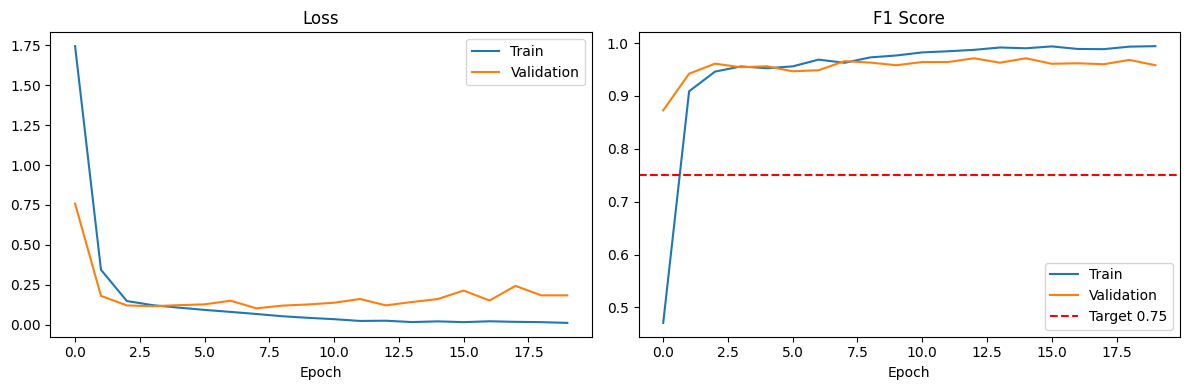

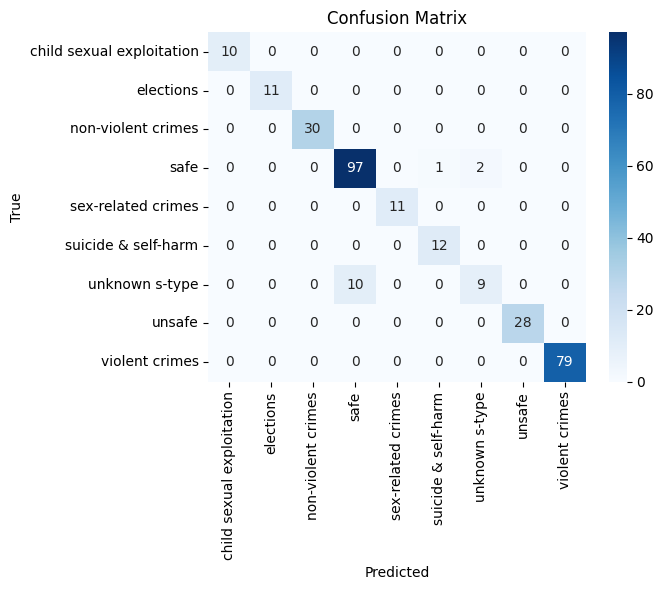

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history["train_loss"], label="Train")
ax[0].plot(history["val_loss"], label="Validation")
ax[0].set_title("Loss"); ax[0].set_xlabel("Epoch"); ax[0].legend()
ax[1].plot(history["train_f1"], label="Train")
ax[1].plot(history["val_f1"], label="Validation")
ax[1].axhline(0.75, color="r", linestyle="--", label="Target 0.75")
ax[1].set_title("F1 Score"); ax[1].set_xlabel("Epoch"); ax[1].legend()
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()